In [ ]:
Machine Learning with Python and PyTorch
Dataset: Groceries
url:  https://raw.githubusercontent.com/shubhamjha97/association-rule-mining-apriori/master/data/groceries.csv
This program features the following concepts:
 - Statistical analysis
 - Data preprocessing for transactions
 - Apriori Algorithm and Association Rules
 - Rich visualizations (Matplotlib, Seaborn, Plotly, NumPy)
 *  Apriori analysis and apriori algorithm (for frequent itemset mining and association rule learning is used to
    find patterns in transactional datasets. An example is from online retailers where the page suggests the
    prospective buyer with the comment: "Who buys this also buys that".)

In [1]:
# Install libraries
!pip install plotly -q

import torch
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!\n")

Libraries imported!



In [2]:
url = "https://raw.githubusercontent.com/shubhamjha97/association-rule-mining-apriori/master/data/groceries.csv"

response = requests.get(url)
response.raise_for_status()

transactions = []
for line in response.text.splitlines():
    items = [item.strip() for item in line.strip().split(',') if item.strip()]
    if items:
        transactions.append(items)

print(f"Dataset Loaded! Total Transactions: {len(transactions):,}")

# Create unique items mapping
all_items = sorted(set(item for transaction in transactions for item in transaction))
item_to_idx = {item: idx for idx, item in enumerate(all_items)}
num_items = len(all_items)

print(f"Total Unique Items: {num_items}")


Dataset Loaded! Total Transactions: 9,835
Total Unique Items: 169


In [3]:
# Convert to PyTorch tensor
# One-hot encode transactions
data = torch.zeros((len(transactions), num_items), dtype=torch.float32, device='cpu')

for i, transaction in enumerate(transactions):
    for item in transaction:
        if item in item_to_idx:
            data[i, item_to_idx[item]] = 1

print(f"Transaction tensor shape: {data.shape}")

Transaction tensor shape: torch.Size([9835, 169])


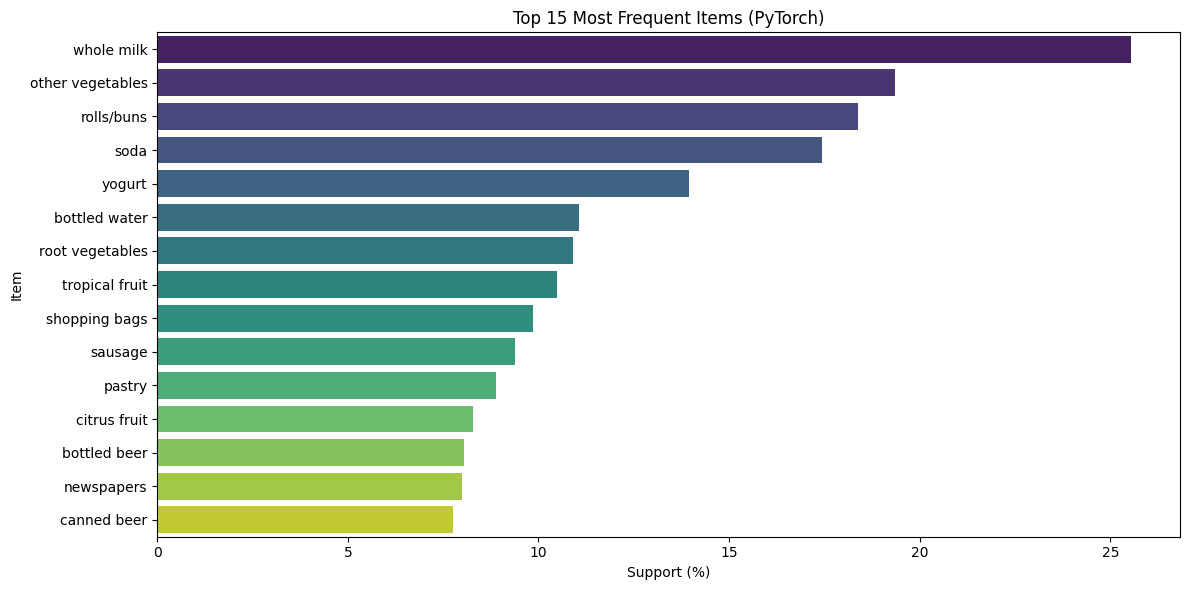


Top 10 Items:
                 Item  Support (%)
166        whole milk    25.551601
103  other vegetables    19.349262
123        rolls/buns    18.393494
139              soda    17.437721
167            yogurt    13.950178
13      bottled water    11.052364
124   root vegetables    10.899848
158    tropical fruit    10.493137
134     shopping bags     9.852568
131           sausage     9.395018


In [4]:
# Statistical Analysis
item_support = data.mean(dim=0) * 100  # percentage

top_items = pd.DataFrame({
    'Item': all_items,
    'Support (%)': item_support.cpu().numpy()
}).sort_values('Support (%)', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items['Support (%)'].head(15),
            y=top_items['Item'].head(15),
            palette='viridis')
plt.title('Top 15 Most Frequent Items (PyTorch)')
plt.xlabel('Support (%)')
plt.tight_layout()
plt.show()

print("\nTop 10 Items:")
print(top_items.head(10))

In [5]:
# Apriori
def find_frequent_itemsets(data, min_support=0.005):
    min_count = int(min_support * len(data))
    frequent = []

    # Single items
    support = data.sum(dim=0)
    valid = support >= min_count
    frequent.append((torch.where(valid)[0], support[valid]))

    print(f"Found {valid.sum().item()} frequent single items")

    # For simplicity, we'll stop at 2-itemsets (higher order is expensive)
    # You can extend this for 3+ itemsets if needed
    idx = torch.where(valid)[0]
    for i in range(len(idx)):
        for j in range(i+1, len(idx)):
            item1, item2 = idx[i], idx[j]
            pair_support = (data[:, item1] * data[:, item2]).sum()
            if pair_support >= min_count:
                frequent.append((torch.tensor([item1, item2]), pair_support))

    return frequent

print("\n Finding Frequent Itemsets...")
frequent_itemsets = find_frequent_itemsets(data, min_support=0.005)


 Finding Frequent Itemsets...
Found 120 frequent single items


In [8]:
# Association rules
min_support_count = int(0.005 * len(data))   # This line must be executed before the loop

rules = []
# Check 2-item combinations (most common for association rules)
print("🔍 Generating Association Rules...")
for i in range(num_items):
    for j in range(i+1, num_items):
        support_ij = (data[:, i] * data[:, j]).sum().item()

        if support_ij >= min_support_count:
            supp = support_ij / len(data)

            # Confidence i => j
            conf_ij = support_ij / (data[:, i].sum().item() + 1e-8)
            # Confidence j => i
            conf_ji = support_ij / (data[:, j].sum().item() + 1e-8)

            lift_ij = conf_ij / (data[:, j].mean().item() + 1e-8)

            if lift_ij > 1.0:
                rules.append({
                    'antecedent': all_items[i],
                    'consequent': all_items[j],
                    'support': supp,
                    'confidence': conf_ij,
                    'lift': lift_ij
                })

rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False)
print(f"\n✅ Strong Association Rules Found: {len(rules_df)}")
display(rules_df.head(15))

🔍 Generating Association Rules...

✅ Strong Association Rules Found: 585


,antecedent,consequent,support,confidence,lift
280,flour,sugar,0.004982,0.286550,8.463110
345,ham,white bread,0.005084,0.195312,4.639850
361,herbs,root vegetables,0.007016,0.431250,3.956477
33,berries,whipped/sour cream,0.009049,0.272171,3.796885
363,hygiene articles,napkins,0.006101,0.185185,3.536497
131,candy,chocolate,0.004982,0.166667,3.358947
147,chicken,frozen vegetables,0.006711,0.156398,3.251956
540,sausage,sliced cheese,0.007016,0.074675,3.047434
19,beef,root vegetables,0.017387,0.331395,3.040366
173,chocolate,waffles,0.005796,0.116803,3.039048


In [11]:
# Visualizations: Scatter plot
fig = px.scatter(rules_df.head(80),
                 x='confidence',
                 y='lift',
                 color='support',
                 size='support',
                 hover_data=['antecedent', 'consequent'],
                 title='Association Rules (PyTorch Implementation)')
fig.show()

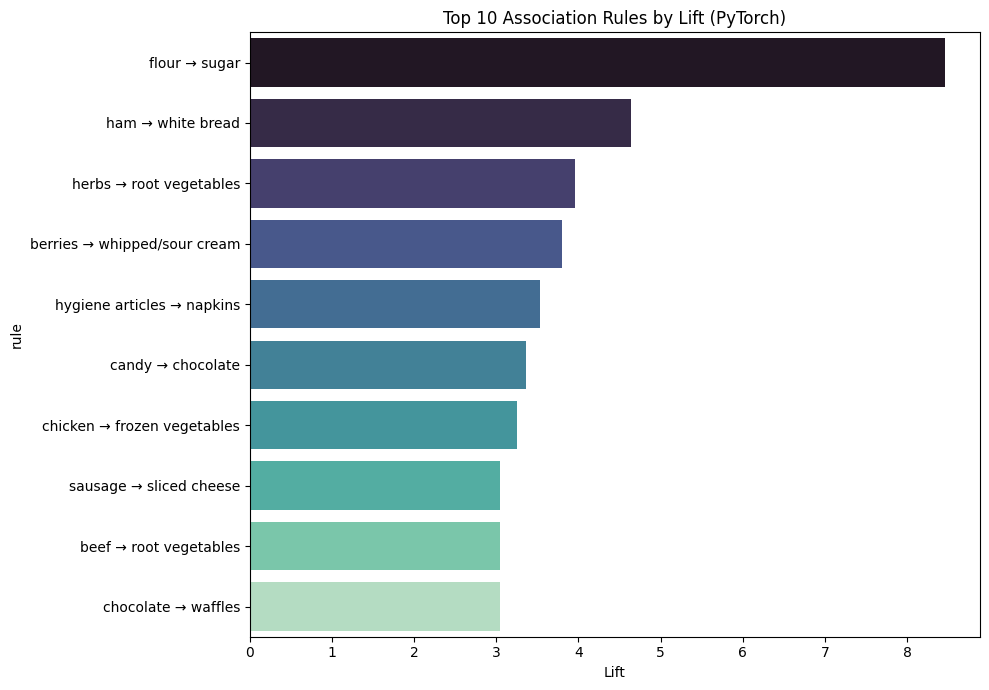

In [14]:
# Visualizations
# Top Rules
top10 = rules_df.head(10).copy()
top10['rule'] = top10['antecedent'] + " → " + top10['consequent']

plt.figure(figsize=(10, 7))
sns.barplot(x='lift', y='rule', data=top10, palette='mako')
plt.title('Top 10 Association Rules by Lift (PyTorch)')
plt.xlabel('Lift')
plt.tight_layout()
plt.show()

In [15]:
# Business insights
print("\n" + "="*70)
print("💡 TOP 5 RECOMMENDATIONS")
print("="*70)
for i, row in rules_df.head(5).iterrows():
    print(f"{i+1}. If buys **{row['antecedent']}** → Recommend **{row['consequent']}**")
    print(f"   Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}\n")


💡 TOP 5 RECOMMENDATIONS
281. If buys **flour** → Recommend **sugar**
   Confidence: 28.7% | Lift: 8.46

346. If buys **ham** → Recommend **white bread**
   Confidence: 19.5% | Lift: 4.64

362. If buys **herbs** → Recommend **root vegetables**
   Confidence: 43.1% | Lift: 3.96

34. If buys **berries** → Recommend **whipped/sour cream**
   Confidence: 27.2% | Lift: 3.80

364. If buys **hygiene articles** → Recommend **napkins**
   Confidence: 18.5% | Lift: 3.54

